# Phase 9 — Walk-Forward Validation

**Strategy**: Momentum → Top-5 → 200DMA filter → HRP weighting

The full backtest is already sequential with no look-ahead (HRP weights computed from rolling 36-month window at each month-end). This notebook slices that return series into annual folds and checks metric consistency across time.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from src.data import load_prices, compute_returns, load_risk_free_rate
from src.backtest import load_backtest_returns
from src.walk_forward import run_walk_forward, print_walk_forward_table

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


In [2]:
prices     = load_prices(directory='../data/processed')
returns    = compute_returns(prices)
rf_daily   = load_risk_free_rate(directory='../data/processed')
rf_monthly = (1 + rf_daily).resample('ME').prod() - 1

bt_rets  = load_backtest_returns(directory='../data/processed')
hrp_ret  = bt_rets['D: HRP'].dropna()
spy_ret  = prices.resample('ME').last()['SPY'].pct_change().dropna()

df = run_walk_forward(hrp_ret, spy_ret, rf_monthly)
print_walk_forward_table(df)

folds = df[df.index != 'Full Period']


  WALK-FORWARD VALIDATION — Momentum → Top-5 → 200DMA → HRP
  Fold           N    CAGR%   Sharpe   MaxDD%   Calmar    SPY%    Alpha
  ──────────── ───  ───────  ───────  ───────  ───────  ──────  ───────
  2005          12     3.19    0.269     0.00      nan    7.92    -4.73
  2006          12    22.02    2.217    -3.54    6.225   15.85     6.17 ★
  2007          12    16.74    1.024    -4.89    3.426    5.15    11.59 ★
  2008          12     7.47    0.444    -8.23    0.907  -36.80    44.27 ★
  2009          12     3.27    0.243    -7.65    0.428   26.35   -23.08
  2010          12    16.84    1.168   -10.08    1.671   15.06     1.78 ★
  2011          12    18.26    1.271    -9.25    1.975    1.89    16.37 ★
  2012          12     8.52    1.233    -3.90    2.183   15.99    -7.47
  2013          12    13.19    1.303    -6.44    2.049   32.31   -19.12
  2014          12    16.48    1.841    -3.54    4.654   13.46     3.02 ★
  2015          12   -12.26   -2.227   -11.05   -1.109    1.23 

## Per-Fold CAGR: HRP vs SPY

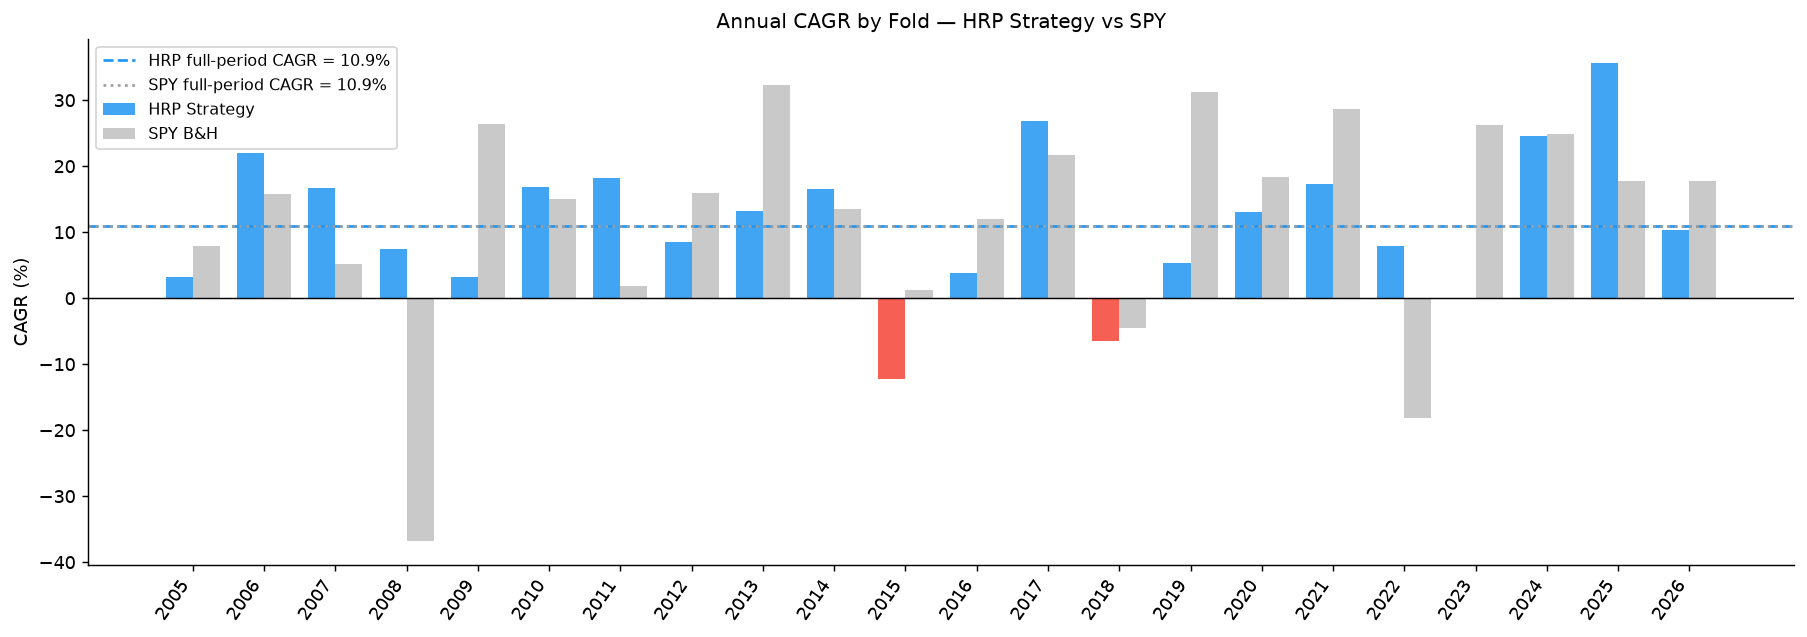

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(folds))
w     = 0.38
hrp_c = folds['CAGR %'].values
spy_c = folds['SPY CAGR %'].values

bars_h = ax.bar(x - w/2, hrp_c, w, label='HRP Strategy',
                color=['#2196F3' if v >= 0 else '#F44336' for v in hrp_c], alpha=0.85)
bars_s = ax.bar(x + w/2, spy_c, w, label='SPY B&H',
                color='#9E9E9E', alpha=0.55)

ax.axhline(0, color='black', linewidth=0.8)
full = df.loc['Full Period']
ax.axhline(full['CAGR %'], color='#2196F3', linewidth=1.5, linestyle='--',
           label=f"HRP full-period CAGR = {full['CAGR %']:.1f}%")
ax.axhline(full['SPY CAGR %'], color='#9E9E9E', linewidth=1.5, linestyle=':',
           label=f"SPY full-period CAGR = {full['SPY CAGR %']:.1f}%")

ax.set_xticks(x)
ax.set_xticklabels(folds.index, rotation=55, ha='right')
ax.set_ylabel('CAGR (%)')
ax.set_title('Annual CAGR by Fold — HRP Strategy vs SPY')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Per-Fold Sharpe Ratio

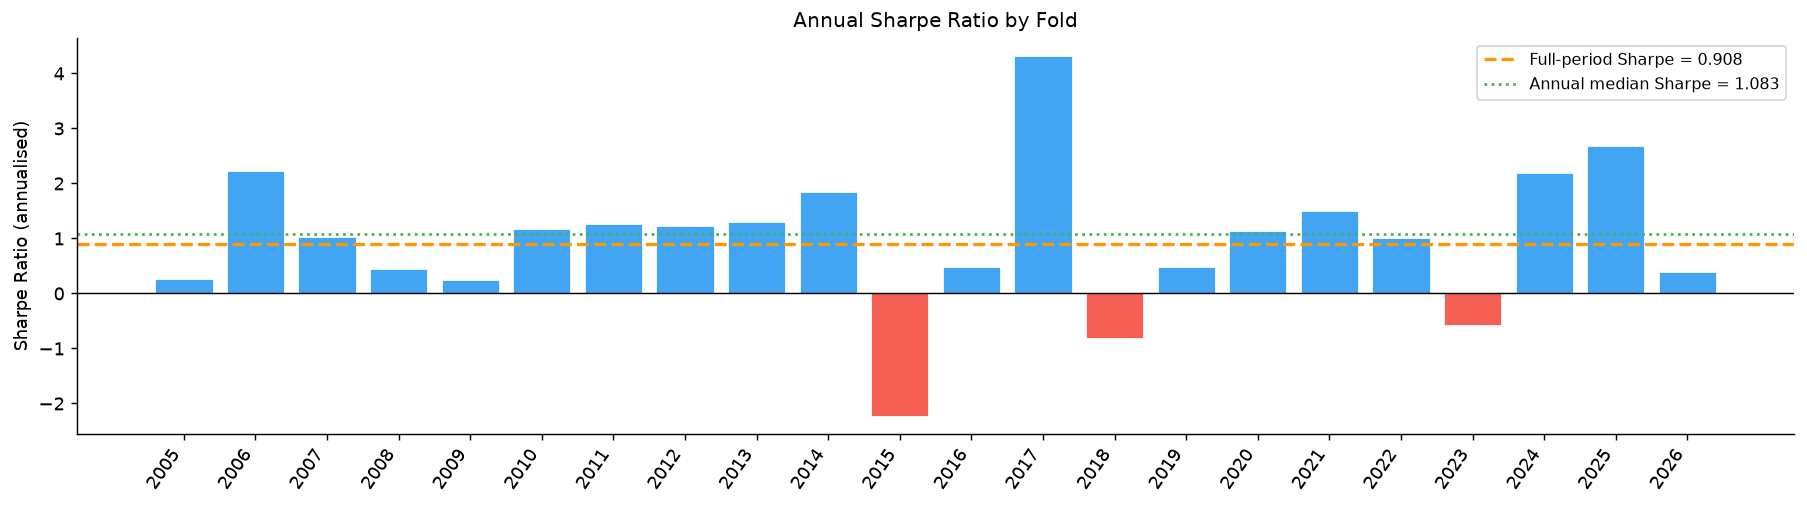

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
sh = folds['Sharpe'].values
cols = ['#2196F3' if v >= 0 else '#F44336' for v in sh]
ax.bar(x, sh, color=cols, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(0,    color='black', linewidth=0.8)
ax.axhline(full['Sharpe'], color='#FF9800', linewidth=1.8, linestyle='--',
           label=f"Full-period Sharpe = {full['Sharpe']:.3f}")
ax.axhline(np.nanmedian(sh), color='#4CAF50', linewidth=1.5, linestyle=':',
           label=f"Annual median Sharpe = {np.nanmedian(sh):.3f}")

ax.set_xticks(x)
ax.set_xticklabels(folds.index, rotation=55, ha='right')
ax.set_ylabel('Sharpe Ratio (annualised)')
ax.set_title('Annual Sharpe Ratio by Fold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Per-Fold Max Drawdown

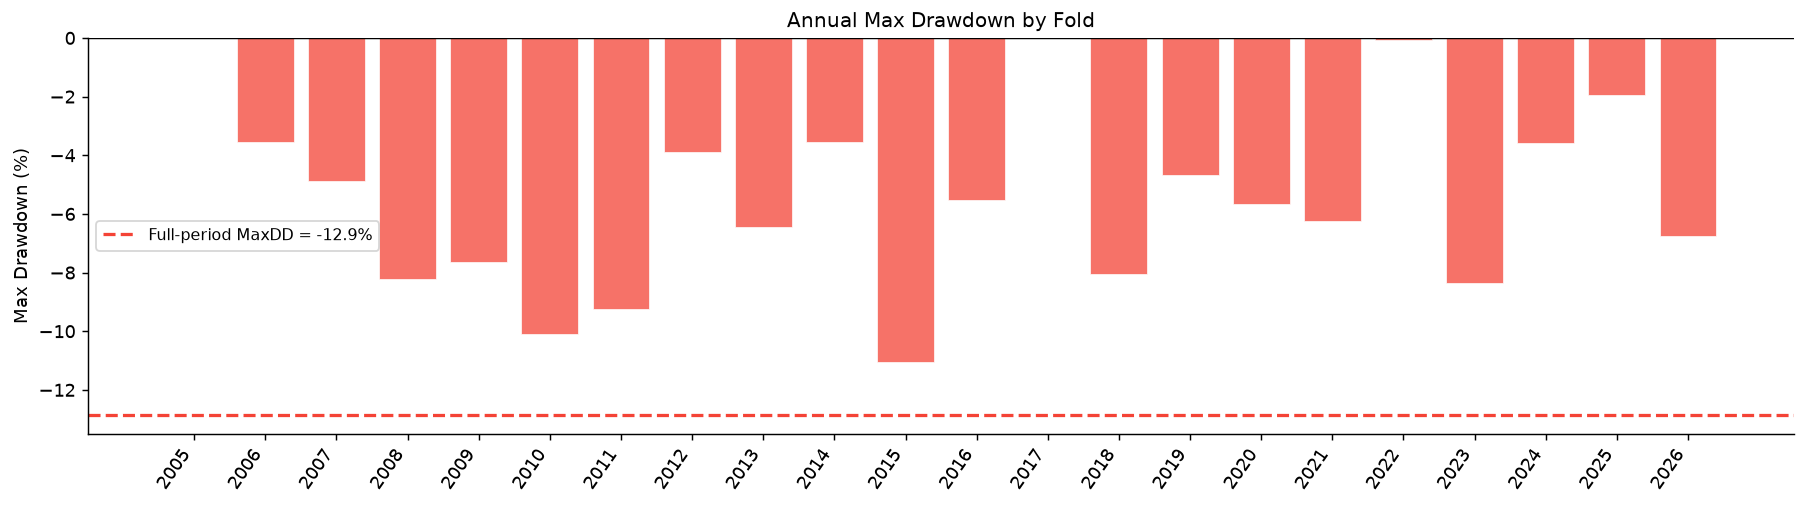

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
mdd = folds['MaxDD %'].values
ax.bar(x, mdd, color='#F44336', alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(full['MaxDD %'], color='#F44336', linewidth=1.8, linestyle='--',
           label=f"Full-period MaxDD = {full['MaxDD %']:.1f}%")

ax.set_xticks(x)
ax.set_xticklabels(folds.index, rotation=55, ha='right')
ax.set_ylabel('Max Drawdown (%)')
ax.set_title('Annual Max Drawdown by Fold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Per-Fold Calmar Ratio

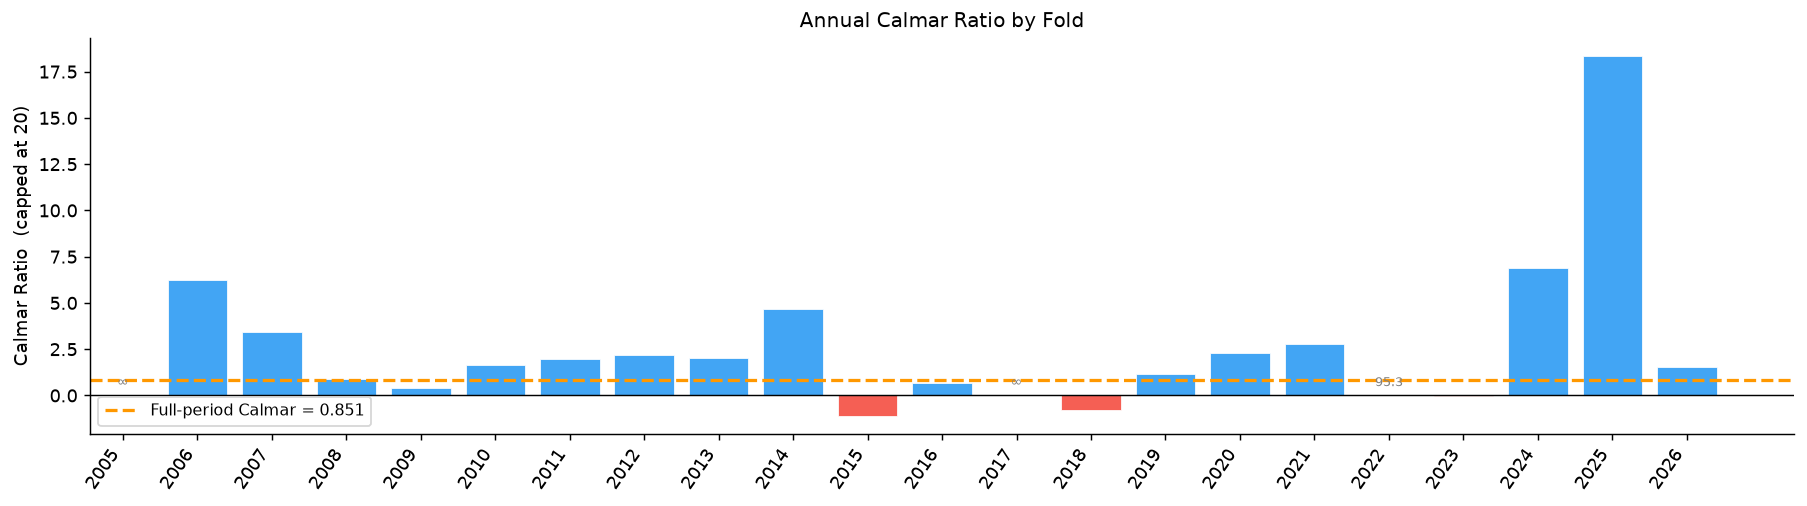

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
cal = folds['Calmar'].values
# Clip extreme values for display (2017 has inf Calmar due to 0 MaxDD)
cal_disp = np.where(np.isnan(cal) | (np.abs(cal) > 20), np.nan, cal)
cols = ['#2196F3' if (v is not None and not np.isnan(v) and v >= 0) else '#F44336'
        for v in cal_disp]
ax.bar(x, cal_disp, color=cols, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(full['Calmar'], color='#FF9800', linewidth=1.8, linestyle='--',
           label=f"Full-period Calmar = {full['Calmar']:.3f}")

# Mark extreme/nan folds
for i, (raw, disp) in enumerate(zip(cal, cal_disp)):
    if np.isnan(disp) and not np.isnan(raw) if not (raw is None) else False:
        ax.text(i, 0.5, f'{raw:.1f}', ha='center', fontsize=7, color='gray')
    elif np.isnan(disp):
        ax.text(i, 0.5, '∞' if (not np.isnan(folds['CAGR %'].values[i]) and folds['CAGR %'].values[i]>0) else 'n/a',
                ha='center', fontsize=8, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(folds.index, rotation=55, ha='right')
ax.set_ylabel('Calmar Ratio  (capped at 20)')
ax.set_title('Annual Calmar Ratio by Fold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Equity Curve with Annual Fold Boundaries

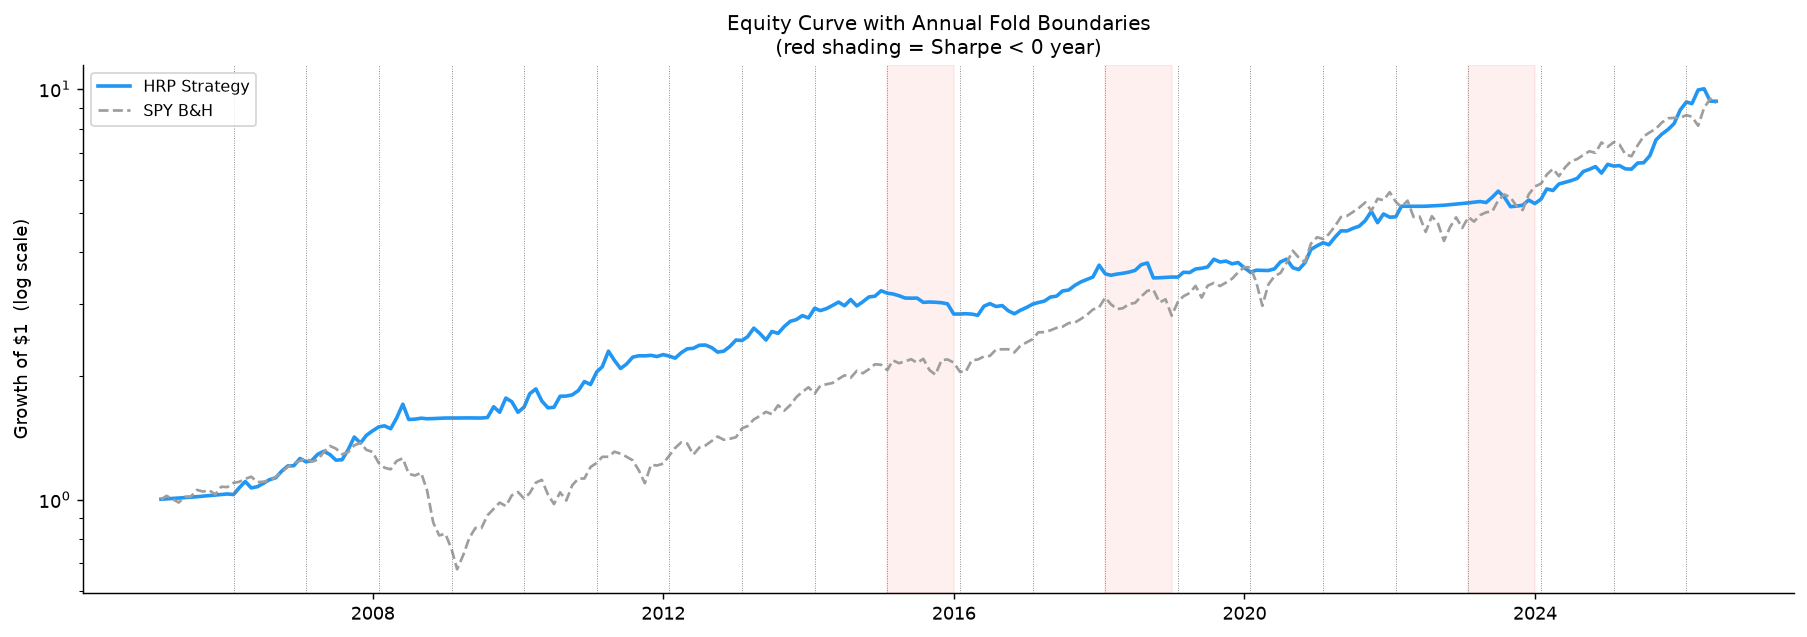

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

hrp_eq = (1 + hrp_ret).cumprod()
spy_eq = (1 + spy_ret.reindex(hrp_ret.index).fillna(0)).cumprod()

ax.plot(hrp_eq.index, hrp_eq.values, color='#2196F3', linewidth=2, label='HRP Strategy')
ax.plot(spy_eq.index, spy_eq.values, color='#9E9E9E', linewidth=1.5, linestyle='--', label='SPY B&H')

# Fold boundaries
for yr in sorted(hrp_ret.index.year.unique())[1:]:
    mask = hrp_ret.index.year == yr
    if mask.any():
        boundary = hrp_ret.index[mask][0]
        ax.axvline(boundary, color='gray', linewidth=0.5, linestyle=':')

# Shade negative-Sharpe folds
sh_by_yr = folds['Sharpe'].to_dict()
for yr, sh in sh_by_yr.items():
    if not np.isnan(sh) and sh < 0:
        mask = hrp_ret.index.year == int(yr)
        if mask.any():
            start = hrp_ret.index[mask][0]
            end   = hrp_ret.index[mask][-1]
            ax.axvspan(start, end, alpha=0.08, color='#F44336')

ax.set_yscale('log')
ax.set_ylabel('Growth of $1  (log scale)')
ax.set_title('Equity Curve with Annual Fold Boundaries\n(red shading = Sharpe < 0 year)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Consistency Summary Dashboard

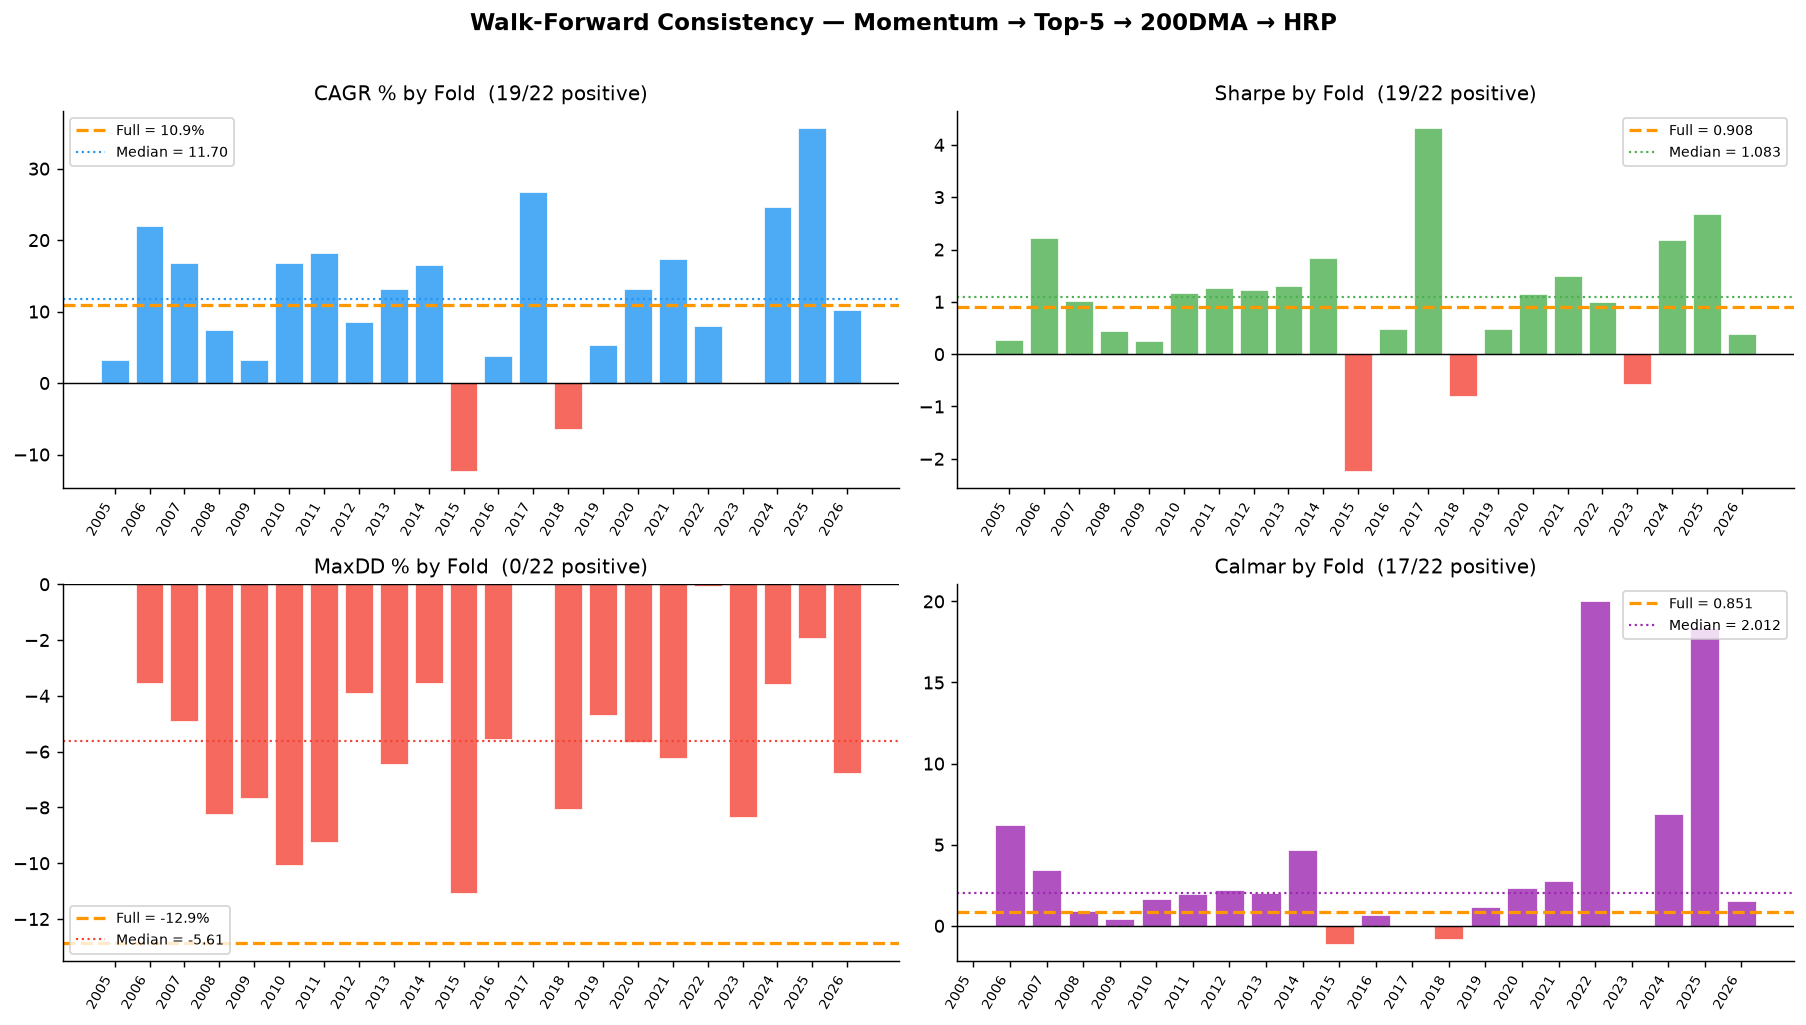


  Per-fold distribution (22 annual folds):
  Metric           Min       P25    Median       P75       Max   %Positive
  CAGR %        -12.26      4.16     11.70     17.24     35.66         86%
  Sharpe         -2.23      0.41      1.08      1.45      4.32         86%
  MaxDD %       -11.05     -7.94     -5.61     -3.55      0.00          0%
  Calmar         -1.11      0.85      2.01      3.73     95.27         85%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics_plot = [
    ('CAGR %',  axes[0,0], '#2196F3', f"Full = {full['CAGR %']:.1f}%"),
    ('Sharpe',  axes[0,1], '#4CAF50', f"Full = {full['Sharpe']:.3f}"),
    ('MaxDD %', axes[1,0], '#F44336', f"Full = {full['MaxDD %']:.1f}%"),
    ('Calmar',  axes[1,1], '#9C27B0', f"Full = {full['Calmar']:.3f}"),
]

for (col, ax, c, lbl) in metrics_plot:
    vals = folds[col].values.astype(float)
    # For Calmar, clip at ±20 for readability
    if col == 'Calmar':
        vals = np.clip(vals, -20, 20)

    colors_m = [c if (not np.isnan(v) and v >= 0) else '#F44336' for v in vals]
    ax.bar(x, vals, color=colors_m, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)

    full_val = float(full[col])
    if col == 'Calmar':
        full_val = np.clip(full_val, -20, 20)
    ax.axhline(full_val, color='#FF9800', linewidth=1.8, linestyle='--', label=lbl)

    med = np.nanmedian(vals)
    ax.axhline(med, color=c, linewidth=1.2, linestyle=':', label=f'Median = {med:.2f}' if col in ['CAGR %','MaxDD %'] else f'Median = {med:.3f}')

    n_pos = int(np.sum(vals > 0))
    ax.set_title(f'{col} by Fold  ({n_pos}/{len(vals)} positive)')
    ax.set_xticks(x)
    ax.set_xticklabels(folds.index, rotation=60, ha='right', fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle('Walk-Forward Consistency — Momentum → Top-5 → 200DMA → HRP', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Summary stats table
print('\n  Per-fold distribution (22 annual folds):')
print(f"  {'Metric':<10}  {'Min':>8}  {'P25':>8}  {'Median':>8}  {'P75':>8}  {'Max':>8}  {'%Positive':>10}")
for col in ['CAGR %', 'Sharpe', 'MaxDD %', 'Calmar']:
    v = folds[col].values.astype(float)
    v_clean = v[~np.isnan(v)]
    p25, med, p75 = np.percentile(v_clean, [25, 50, 75])
    pct_pos = (v_clean > 0).mean() * 100
    print(f"  {col:<10}  {v_clean.min():>8.2f}  {p25:>8.2f}  {med:>8.2f}  {p75:>8.2f}  {v_clean.max():>8.2f}  {pct_pos:>9.0f}%")